In [1]:
import os
import scipy
import pandas as pd
import numpy as np
from typing import List
from sub_tsmd import plot_motif_sets

In [2]:
path_to_raw_data = 'raw-data/'

In [3]:
# Based on work section 3.2 and fig 4 in "Automated evaluation of physical therapy exercises using multi-template dynamic time warping on wearable sensor signals"
units = ['u1', 'u2', 'u3', 'u4', 'u5']
relevant_units = {
    # Sitting on high surface and lifting right leg
    'e1': ['u2', 'u3'],
    # Sitting on stool and bend upper body forward
    'e2': ['u2', 'u3', 'u4', 'u5'],
    # Laying flat on back and raising right leg (left leg keeps still)
    'e3': ['u2', 'u3'],
    # Lying flat on left side and raising right leg (left leg keeps still)
    'e4': ['u2', 'u3'],
    # Lying face down and raising right leg (left leg keeps still)
    'e5': ['u2', 'u3'],
    # Sitting while raising 1kg in front
    'e6': ['u2', 'u3'],
    # Standing while lifting 1kg on your side
    'e7': ['u2', 'u3', 'u4'],
    # Lying on elevated flat surface with elbow at border, and lift forearm to make arm straight
    'e8': ['u2', 'u3', 'u4'],
}

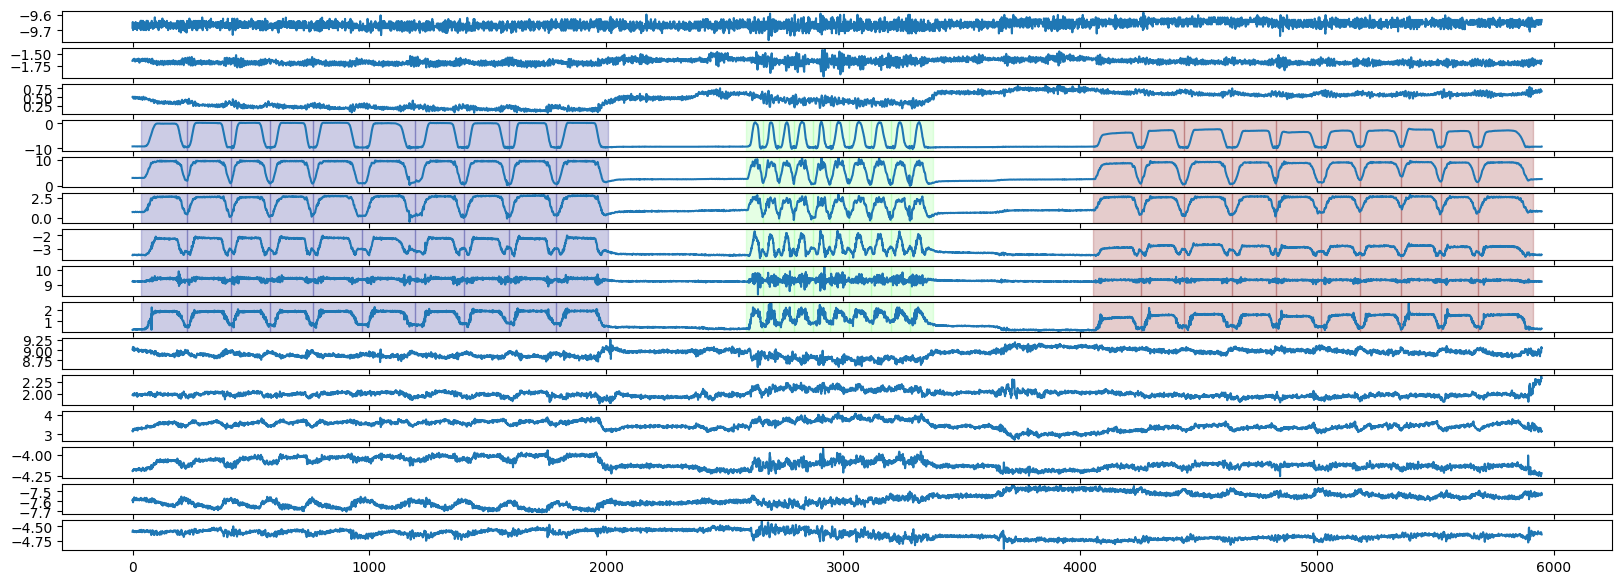

In [4]:
def read_data(subject: str, exercise: str, accelerometer: bool = True, gyroscope: bool = True, magnetometer: bool = True):
    # Get the attributes
    columns = []
    columns += [f"acc_{direction}" for direction in ["x", "y", "z"]] if accelerometer else []
    columns += [f"gyr_{direction}" for direction in ["x", "y", "z"]] if gyroscope else []
    columns += [f"mag_{direction}" for direction in ["x", "y", "z"]] if magnetometer else []
    assert len(columns) != 0, "There should be at least one column selected!"
    
    # Read the data
    df = pd.concat({
        unit: pd.read_csv(f"{path_to_raw_data}/{subject}/{exercise}/{unit}/test.txt", sep=';', usecols=columns, dtype=float)
        for unit in units
    }, axis=1)
    
    # Read the labels
    labels = pd.read_csv(f"{path_to_raw_data}/labels/annotations_{subject}_{exercise}_annotations.csv")
    
    # Format the labels
    mask = df.columns.get_level_values(0).map(lambda x: x in relevant_units[exercise]).to_numpy()
    motif_sets = [
        (mask, np.empty(shape=(labels['type'].value_counts()[exercise_type], 2, mask.sum()), dtype=int))
        for exercise_type in labels['type'].unique()
    ]
    for exercise_type, group in labels.groupby('type'):
        for i, (_, (start, end)) in enumerate(group[['start', 'end']].iterrows()):
            motif_sets[exercise_type][1][i, 0, :] = start
            motif_sets[exercise_type][1][i, 1, :] = end   
    
    # Return the data
    return df.values, motif_sets

X, y = read_data('s1', 'e1', accelerometer=True, gyroscope=False, magnetometer=False)
fig = plot_motif_sets(X, y)

In [5]:
def get_r(X, y, l_min, l_max):
    
    r_max = -np.inf
    length = int(np.round((l_min + l_max) / 2))
    
    for ts, gt in zip(X, y):
        
        for (mask, motif_set) in gt:
        
            instances = np.empty(shape=(motif_set.shape[0], mask.sum(), length))
            for i, motif in enumerate(motif_set):
                c = -1
                for d in range(ts.shape[1]):
                    if not mask[d]:
                        continue
                    c += 1
                    instances[i, c, :] = scipy.signal.resample(ts[motif[0, c]:motif[1, c], d], length)      

            # Compute the distance matrix
            N, D, T = instances.shape
            distance_matrix = scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(instances.reshape(N, D*T), metric='euclidean'))
            
            # Find the R for this class, and update r_max
            r = np.min(np.max(distance_matrix, axis=0))
            if r > r_max:
                r_max = r
    
    return r_max

In [6]:
def generate_benchmark(subjects_validation: List[str], subjects_test: List[str], **kwargs):
    
    columns = {'ds_name': str, 'l_min': int, 'l_max': int, 'D': int, 'g_max' : int, 'r': float, 'n_avg_train': int, 'n_avg_test': int, 'n_avg': int}
    metadata = pd.DataFrame(columns, index=[])

    for exercise in relevant_units:
        
        # Create validation data
        ts_validation, gt_validation = [], []
        for subject in subjects_validation:
            ts, gt = read_data(subject, exercise, **kwargs)
            ts_validation.append(ts)
            gt_validation.append(gt)
            
        # Create test data
        ts_test, gt_test = [], []
        for subject in subjects_test:
            ts, gt = read_data(subject, exercise, **kwargs)
            ts_test.append(ts)
            gt_test.append(gt)
            
        # Save the data 
        if not os.path.exists(exercise.lower()):
            os.mkdir(exercise.lower())       
        pd.DataFrame(data={'ts': ts_validation, 'gt': gt_validation}).to_pickle(f'{exercise.lower()}/validation.pkl')
        pd.DataFrame(data={'ts': ts_test, 'gt': gt_test}).to_pickle(f'{exercise.lower()}/test.pkl')
        
        # Compute the length of each motif
        motif_lengths = []
        for (_, motif_set) in [subject_motif_sets for gt in gt_validation for subject_motif_sets in gt]:
            for motif in motif_set:
                motif_lengths.extend(motif[1] - motif[0])
        
        # Save the meta data 
        metadata.loc[len(metadata)] = {
            'ds_name': exercise.lower(), 
            'D': ts_validation[0].shape[1], 
            'l_min': min(motif_lengths),
            'l_max': max(motif_lengths),
            'k_max': max(motif_set.shape[0] for gt in gt_validation + gt_test for (_, motif_set) in gt ),
            'r': get_r(ts_validation, gt_validation, min(motif_lengths), max(motif_lengths)),
            'n_avg_train': np.mean([i.shape[0] for i in ts_validation]), 
            'n_avg_test': np.mean([i.shape[0] for i in ts_test]), 
            'n_avg': np.mean([i.shape[0] for i in ts_validation + ts_test])
        }
        
    metadata = metadata.set_index('ds_name')
    metadata.to_csv('metadata.csv')
    
    
generate_benchmark(
    subjects_validation=['s1', 's2'],
    subjects_test=['s3', 's4', 's5'], 
    accelerometer=True, 
    gyroscope=False, 
    magnetometer=False
)